## Slade Brooks
### AEEM7063 CFD Homework 3
### 03.30.26

In [85]:
import numpy as np
import math
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [86]:
class ExactSodSolver:
    def __init__(self, rhoL, uL, pL, rhoR, uR, pR, gamma=1.4, x0=0.5):
        self.rhoL = rhoL
        self.uL   = uL
        self.pL   = pL
        self.rhoR = rhoR
        self.uR   = uR
        self.pR   = pR
        self.gamma = gamma
        self.x0 = x0

        # Precompute sound speeds
        self.aL = math.sqrt(self.gamma * self.pL / self.rhoL)
        self.aR = math.sqrt(self.gamma * self.pR / self.rhoR)

        # Compute star-region pressure and velocity
        self.p_star, self.u_star = self._solve_star_region()

    # ------------------------------------------------------------------
    # 1. Functions defining the wave curves for L and R
    # ------------------------------------------------------------------
    def _f_shock(self, p, rho_k, p_k):
        """Shock branch: f_k(p) for p > p_k."""
        g = self.gamma
        A = 2.0 / ((g + 1.0) * rho_k)
        B = (g - 1.0) / (g + 1.0) * p_k
        return (p - p_k) * math.sqrt(A / (p + B))

    def _f_rarefaction(self, p, rho_k, p_k, a_k):
        """Rarefaction branch: f_k(p) for p <= p_k."""
        g = self.gamma
        return (2.0 * a_k / (g - 1.0)) * ((p / p_k)**((g - 1.0) / (2.0 * g)) - 1.0)

    def _f_and_df(self, p):
        """
        Returns F(p) = f_L(p) + f_R(p) + (u_R - u_L)
        and its derivative F'(p) for Newton iteration.
        """
        g = self.gamma

        # Left side
        if p > self.pL:  # left shock
            A_L = 2.0 / ((g + 1.0) * self.rhoL)
            B_L = (g - 1.0) / (g + 1.0) * self.pL
            fL = (p - self.pL) * math.sqrt(A_L / (p + B_L))
            dfL = math.sqrt(A_L / (p + B_L)) * (1.0 - 0.5 * (p - self.pL) / (p + B_L))
        else:  # left rarefaction
            fL = self._f_rarefaction(p, self.rhoL, self.pL, self.aL)
            dfL = (1.0 / (self.rhoL * self.aL)) * (p / self.pL)**(-(self.gamma + 1.0) / (2.0 * self.gamma))

        # Right side
        if p > self.pR:  # right shock
            A_R = 2.0 / ((g + 1.0) * self.rhoR)
            B_R = (g - 1.0) / (g + 1.0) * self.pR
            fR = (p - self.pR) * math.sqrt(A_R / (p + B_R))
            dfR = math.sqrt(A_R / (p + B_R)) * (1.0 - 0.5 * (p - self.pR) / (p + B_R))
        else:  # right rarefaction
            fR = self._f_rarefaction(p, self.rhoR, self.pR, self.aR)
            dfR = (1.0 / (self.rhoR * self.aR)) * (p / self.pR)**(-(self.gamma + 1.0) / (2.0 * self.gamma))

        F  = fL + fR + (self.uR - self.uL)
        dF = dfL + dfR
        return F, dF

    # ------------------------------------------------------------------
    # 2. Solve for p_star and u_star via Newton iteration
    # ------------------------------------------------------------------
    def _guess_p_star(self):
        """
        Toro's "PVRS" approximate initial guess for p_star.
        """
        g = self.gamma
        pPV = 0.5 * (self.pL + self.pR) + 0.125 * (self.uL - self.uR) * (self.rhoL + self.rhoR) * (self.aL + self.aR)
        pPV = max(1e-8, pPV)

        p_min = min(self.pL, self.pR)
        p_max = max(self.pL, self.pR)

        q = pPV / p_min
        if q <= 0.1 or q >= 10.0:
            # Two-shock approximate Riemann solver (TRRS) or two-rarefaction (TSRS)
            # Use two-rarefaction if both sides are rarefactive
            if pPV < p_min and self._rarefactive():
                pTR = ((self.aL + self.aR - 0.5*(self.gamma-1)*(self.uR - self.uL)) /
                       (self.aL/self.pL**((self.gamma-1)/(2*self.gamma)) +
                        self.aR/self.pR**((self.gamma-1)/(2*self.gamma)))) \
                       ** (2*self.gamma/(self.gamma-1))
                return max(1e-8, pTR)
            else:
                # two-shock approximation
                g1 = (self.gamma - 1.0) / (2.0 * self.gamma)
                g2 = (self.gamma + 1.0) / (2.0 * self.gamma)
                AL = 1.0 / (self.rhoL * (g2 / self.pL + g1 / pPV))
                AR = 1.0 / (self.rhoR * (g2 / self.pR + g1 / pPV))
                pTS = (AL * self.pL + AR * self.pR - (self.uR - self.uL)) / (AL + AR)
                return max(1e-8, pTS)

        return pPV

    def _rarefactive(self):
        """
        Rough test if both waves are likely rarefactions given PVRS p guess.
        """
        return (self.pL >= self.pR and self.uL <= self.uR) or (self.pL <= self.pR and self.uL >= self.uR)

    def _solve_star_region(self, tol=1e-6, max_iter=50):
        p = self._guess_p_star()

        for _ in range(max_iter):
            F, dF = self._f_and_df(p)
            dp = -F / dF
            p_new = p + dp
            if p_new < 1e-8:  # avoid nonphysical negative pressures
                p_new = 1e-8
            if abs(dp) < tol * (p_new + 1e-8):
                p = p_new
                break
            p = p_new

        # Once p_star is known, compute u_star:
        # use left or right branch of f depending on convenience
        if p > self.pL:
            fL = self._f_shock(p, self.rhoL, self.pL)
        else:
            fL = self._f_rarefaction(p, self.rhoL, self.pL, self.aL)

        u_star = self.uL - fL
        return p, u_star

    # ------------------------------------------------------------------
    # 3. Get state (rho, u, p) at position x and time t
    # ------------------------------------------------------------------
    def sample(self, x, t):
        """
        Return (rho, u, p) at position x and time t.
        For t == 0, returns initial data.
        """
        if t == 0.0:
            if x < self.x0:
                return self.rhoL, self.uL, self.pL
            else:
                return self.rhoR, self.uR, self.pR

        xi = (x - self.x0) / t  # self-similar coordinate
        g = self.gamma

        p_star = self.p_star
        u_star = self.u_star

        # --------------------------------------------------------------
        # Left side: shock or rarefaction
        # --------------------------------------------------------------
        if p_star > self.pL:
            # LEFT SHOCK
            # shock speed
            sL = self.uL - self.aL * math.sqrt(0.5 * (g + 1.0)/g * (p_star / self.pL - 1.0) + 1.0)
            if xi < sL:
                # Left data state
                return self.rhoL, self.uL, self.pL
            else:
                # Left star state behind the shock
                rho_star_L = self.rhoL * ((p_star / self.pL + (g - 1.0)/(g + 1.0)) /
                                          ((g - 1.0)/(g + 1.0) * p_star/self.pL + 1.0))
                return rho_star_L, u_star, p_star
        else:
            # LEFT RAREFACTION
            a_star_L = self.aL * (p_star / self.pL)**((g - 1.0) / (2.0 * g))
            head_L = self.uL - self.aL
            tail_L = u_star - a_star_L

            if xi < head_L:
                # undisturbed left state
                return self.rhoL, self.uL, self.pL
            elif head_L <= xi <= tail_L:
                # inside left fan
                u = (2.0 / (g + 1.0)) * (self.aL + 0.5*(g - 1.0)*self.uL + xi)
                a = (2.0 / (g + 1.0)) * (self.aL + 0.5*(g - 1.0)*(self.uL - xi))
                p = self.pL * (a / self.aL)**(2.0 * g / (g - 1.0))
                rho = g * p / (a*a)
                return rho, u, p
            else:
                # left star state
                rho_star_L = self.rhoL * (p_star / self.pL)**(1.0 / g)
                return rho_star_L, u_star, p_star

        # Note: we return above in each branch, but for clarity we’ll
        # handle the right side similarly using a second function.
        # The code below is unreachable due to returns, but I split the
        # logic below into a separate function if more structure is needed.

    # Optional: separate right-side sampling if you want more structure
    def sample_full(self, x, t):
        """
        Full sampling that treats left and right symmetrically.
        Use this instead of sample() if you want a more explicit structure.
        """
        if t == 0.0:
            if x < self.x0:
                return self.rhoL, self.uL, self.pL
            else:
                return self.rhoR, self.uR, self.pR

        g = self.gamma
        xi = (x - self.x0) / t

        p_star = self.p_star
        u_star = self.u_star

        # LEFT
        if p_star > self.pL:
            # left shock
            sL = self.uL - self.aL * math.sqrt(0.5 * (g + 1.0)/g * (p_star / self.pL - 1.0) + 1.0)
            if xi <= sL:
                return self.rhoL, self.uL, self.pL
            else:
                rho_star_L = self.rhoL * ((p_star / self.pL + (g - 1.0)/(g + 1.0)) /
                                          ((g - 1.0)/(g + 1.0) * p_star/self.pL + 1.0))
        else:
            # left rarefaction
            a_star_L = self.aL * (p_star / self.pL)**((g - 1.0) / (2.0 * g))
            head_L = self.uL - self.aL
            tail_L = u_star - a_star_L
            if xi <= head_L:
                return self.rhoL, self.uL, self.pL
            elif xi < tail_L:
                u = (2.0 / (g + 1.0)) * (self.aL + 0.5*(g - 1.0)*self.uL + xi)
                a = (2.0 / (g + 1.0)) * (self.aL + 0.5*(g - 1.0)*(self.uL - xi))
                p = self.pL * (a / self.aL)**(2.0 * g / (g - 1.0))
                rho = g * p / (a*a)
                return rho, u, p
            else:
                rho_star_L = self.rhoL * (p_star / self.pL)**(1.0 / g)

        # RIGHT
        if p_star > self.pR:
            # right shock
            sR = self.uR + self.aR * math.sqrt(0.5 * (g + 1.0)/g * (p_star / self.pR - 1.0) + 1.0)
            if xi >= sR:
                return self.rhoR, self.uR, self.pR
            else:
                rho_star_R = self.rhoR * ((p_star / self.pR + (g - 1.0)/(g + 1.0)) /
                                          ((g - 1.0)/(g + 1.0) * p_star/self.pR + 1.0))
        else:
            # right rarefaction
            a_star_R = self.aR * (p_star / self.pR)**((g - 1.0) / (2.0 * g))
            head_R = self.uR + self.aR
            tail_R = u_star + a_star_R
            if xi >= head_R:
                return self.rhoR, self.uR, self.pR
            elif xi > tail_R:
                u = (2.0 / (g + 1.0)) * (-self.aR + 0.5*(g - 1.0)*self.uR + xi)
                a = (2.0 / (g + 1.0)) * (-self.aR + 0.5*(g - 1.0)*(xi - self.uR))
                p = self.pR * (a / self.aR)**(2.0 * g / (g - 1.0))
                rho = g * p / (a*a)
                return rho, u, p
            else:
                rho_star_R = self.rhoR * (p_star / self.pR)**(1.0 / g)

        # Between left and right star regions (i.e., around contact)
        if xi <= u_star:
            return rho_star_L, u_star, p_star
        else:
            return rho_star_R, u_star, p_star

# Part 1

For all of the schemes, the following will happen:
1. set grid spacing and timing (length, num points, num time steps)
2. set initial conditions for primitives ($\rho$, p, u)
3. convert primitive to conservative
4. loop through time:
    - determine $\Delta t$ from CFL
    - DO SCHEME HERE
    - set boundary conditions (constants)
    - convert conservative to primitive for next step

The answers in the following sections for each part will show the pseudo code that will be inserted in the lines "DO
SCHEME HERE" to solve the specific scheme.

## (a) FTBS Conservative Flux
$$
\frac{\partial U}{\partial t}+\frac{\partial F}{\partial x}=0
$$

FTBS:
$
\frac{U_i^{n+1}-U_i^n}{\Delta t}+\frac{F_i^n-F_{i-1}^n}{\Delta x}=0
$

for each time step:
- for each grid point i except boundaries:
    - calculate flux from U: $F_i^n=F(U_i^n)$
    - calculate updated time step:
    $
    U_i^{n+1}=-\Delta t\frac{F_i^n-F_{i-1}^n}{\Delta x}+U_i^n
    $

## (b) FTCS Primitive Jacobian
$$
\frac{\partial}{\partial t}\begin{bmatrix}
    \rho \\ u \\ p
\end{bmatrix} + \begin{bmatrix}
    u & \rho & 0 \\ 0 & u & 1/\rho \\ 0 & \gamma p & u
\end{bmatrix}\frac{\partial}{\partial x}\begin{bmatrix}
    \rho \\ u \\ p
\end{bmatrix} = \begin{bmatrix}
    0 \\ 0 \\ 0
\end{bmatrix}
$$

$$
q=\begin{bmatrix}\rho \\ u \\ p\end{bmatrix};\quad J=\begin{bmatrix}u & \rho & 0 \\ 0 & u & 1/\rho \\ 0 & \gamma p & u\end{bmatrix}
$$

$$
\frac{\partial q}{\partial t}+J\frac{\partial q}{\partial x}=0
$$

FTCS:
$
\frac{q_i^{n+1}-q_i^n}{\Delta t}+J\frac{q_{i+1}^n-q_{i-1}^n}{2\Delta x}=0
$

for each time step:
- for each grid point i except boundaries:
    - calculate jacobian from primitives at current time step n
    - calculate updated time step: $q_i^{n+1}=-\Delta tJ\frac{q_{i+1}^n-q_{i-1}^n}{2\Delta x}+q_i^n$

## (c) MacCormack Conservative Flux
$$
\frac{\partial U}{\partial t}+\frac{\partial F}{\partial x}=0
$$

MacCormack Step 1: $
\frac{U_i^{n+1/2}-U_i^n}{\Delta t}+\frac{F_{i+1}^n-F_i^n}{\Delta x}=0
$

MacCormack Step 2: $
\frac{U_i^{n+1}-1/2\left(U_i^n+U_i^{n+1/2}\right)}{\Delta t}+\frac{F_i^{n+1/2}-F_{i-1}^{n+1/2}}{2\Delta x}=0
$

for each time step:
- for each grid point i except boundaries:
    - perform step 1: $U_i^{n+1/2}=-\Delta t\frac{F_{i+1}^n-F_i^n}{\Delta x}+U_i^n$
    - calculate the 1/2 step flux: $F_i^{n+1/2}=F(U_i^{n+1/2})$
- for each grid point i except boundaries again:
    - now do step 2 to solve for time update full step: $U_i^{n+1}=-\Delta t\frac{F_i^{n+1/2}-F_{i-1}^{n+1/2}}{2\Delta
      x} + 1/2\left(U_i^n+U_i^{n+1/2}\right)$

## (d) MacCormack Primitive Jacobian
$$
\frac{\partial}{\partial t}\begin{bmatrix}
    \rho \\ u \\ p
\end{bmatrix} + \begin{bmatrix}
    u & \rho & 0 \\ 0 & u & 1/\rho \\ 0 & \gamma p & u
\end{bmatrix}\frac{\partial}{\partial x}\begin{bmatrix}
    \rho \\ u \\ p
\end{bmatrix} = \begin{bmatrix}
    0 \\ 0 \\ 0
\end{bmatrix}
$$

$$
q=\begin{bmatrix}\rho \\ u \\ p\end{bmatrix};\quad J=\begin{bmatrix}u & \rho & 0 \\ 0 & u & 1/\rho \\ 0 & \gamma p & u\end{bmatrix}
$$

$$
\frac{\partial q}{\partial t}+J\frac{\partial q}{\partial x}=0
$$

MacCormack Step 1: $
\frac{q_i^{n+1/2}-q_i^n}{\Delta t}+J\frac{q_{i+1}^n-q_i^n}{\Delta x}=0
$

MacCormack Step 2: $
\frac{q_i^{n+1}-1/2\left(q_i^n+q_i^{n+1/2}\right)}{\Delta t}+J\frac{q_i^{n+1/2}-q_{i-1}^{n+1/2}}{2\Delta x}=0
$

for each time step:
- for each grid point i except boundaries:
    - calculate jacobian from primitives
    - perform step 1: $q_i^{n+1/2}=-J\Delta t\frac{q_{i+1}^n-q_i^n}{\Delta x}+q_i^n$
    - calculate the 1/2 step jacobian $J^{1/2}$ from $q_i^{n+1/2}$ primitives
- for each grid point i except boundaries again:
    - now do step 2 to solve for time update full step: $q_i^{n+1}=-J^{1/2}\Delta t\frac{q_i^{n+1/2}-q_{i-1}^{n+1/2}}{2\Delta
      x} + 1/2\left(q_i^n+q_i^{n+1/2}\right)$

## (e) MacCormack Conservative Flux w/ Artifical Viscosity
$$
\frac{\partial U}{\partial t}+\frac{\partial F}{\partial x}=\alpha\frac{\partial^2 F}{\partial x^2}
$$

MacCormack Step 1: $
\frac{U_i^{n+1/2}-U_i^n}{\Delta t}+\frac{F_{i+1}^n-F_i^n}{\Delta x}=0
$

MacCormack Step 2: $
\frac{U_i^{n+1}-1/2\left(U_i^n+U_i^{n+1/2}\right)}{\Delta t}+\frac{F_i^{n+1/2}-F_{i-1}^{n+1/2}}{2\Delta x}=0
$

Added viscosity: $U_i^{n+1}+\alpha\left(U_{i+1}^{n+1}-2U_i^{n+1}+U_{i-1}^{n+1}\right)$

for each time step:
- for each grid point i except boundaries:
    - perform step 1: $U_i^{n+1/2}=-\Delta t\frac{F_{i+1}^n-F_i^n}{\Delta x}+U_i^n$
    - calculate the 1/2 step flux: $F_i^{n+1/2}=F(U_i^{n+1/2})$
- for each grid point i except boundaries again:
    - now do step 2 to solve for time update full step: $U_i^{n+1}=-\Delta t\frac{F_i^{n+1/2}-F_{i-1}^{n+1/2}}{2\Delta
      x} + 1/2\left(U_i^n+U_i^{n+1/2}\right)$
- for each grid point i except boundaries again:
    - add artificial viscosity: $U_i^{n+1} \mathrel{{+}{=}} \alpha\left(U_{i+1}^{n+1}-2U_i^{n+1}+U_{i-1}^{n+1}\right)$

## (f) Split Jacobian Primitive
$$
\frac{\partial}{\partial t}\begin{bmatrix}
    \rho \\ u \\ p
\end{bmatrix} + \begin{bmatrix}
    u & \rho & 0 \\ 0 & u & 1/\rho \\ 0 & \gamma p & u
\end{bmatrix}\frac{\partial}{\partial x}\begin{bmatrix}
    \rho \\ u \\ p
\end{bmatrix} = \begin{bmatrix}
    0 \\ 0 \\ 0
\end{bmatrix}
$$

$$
q=\begin{bmatrix}\rho \\ u \\ p\end{bmatrix};\quad J=\begin{bmatrix}u & \rho & 0 \\ 0 & u & 1/\rho \\ 0 & \gamma p & u\end{bmatrix}
$$

$$
\frac{\partial q}{\partial t}+J\frac{\partial q}{\partial x}=0
$$

not going to write the whole thing: $J_C=V\begin{bmatrix}u-c & 0 & 0 \\ 0 & u & 0 \\ 0 & 0 & u+c\end{bmatrix}V^{-1}$

$$
\frac{\partial q}{\partial t}+J^+\frac{\partial q}{\partial x}+J^-\frac{\partial q}{\partial x}=0
$$

for each time step:
- for each grid point i except boundaries:
    - calculate jacobian from primitives
    - get positive and negative jacobians $J^+$=min($J_C$, 0); $J^-$=max($J_C$, 0)
    - solve for next time step: $q_i^{n+1}=-\Delta tq_i^n\left(J^+\frac{q_i^n-q_{i-1}^n}{\Delta x} +
      J^-\frac{q_{i+1}^n-q_i^n}{\Delta x}\right)$

## (g) Split Jacobian Conservative
$$
\frac{\partial U}{\partial t}+J_C\frac{\partial U}{\partial x}=0
$$

not going to write the whole thing: $J_C=V\begin{bmatrix}u-c & 0 & 0 \\ 0 & u & 0 \\ 0 & 0 & u+c\end{bmatrix}V^{-1}$

$$
\frac{\partial U}{\partial t}+J^+\frac{\partial U}{\partial x}+J^-\frac{\partial U}{\partial x}=0
$$

for each time step:
- for each grid point i except boundaries:
    - get positive and negative jacobians $J^+$=min($J_C$, 0); $J^-$=max($J_C$, 0)
    - solve for next time step: $U_i^{n+1}=-\Delta tU_i^n\left(J^+\frac{U_i^n-U_{i-1}^n}{\Delta x} +
      J^-\frac{U_{i+1}^n-U_i^n}{\Delta x}\right)$

## (h) Godunov HLLC
$$
\frac{\partial U}{\partial t}+\frac{\partial F}{\partial x}=0
$$

for each time step:
- for each grid point i except boundaries:
    - calculate foreward half step: $F_{i+1/2}^n=\text{HLLC}\left(U_i^n, U_{i+1}^n\right)$
    - calculate backwards half step: $F_{i-1/2}^n=\text{HLLC}\left(U_{i-1}^n, U_i^n\right)$
    - solve for next time step: $U_i^{n+1}=-\Delta t\frac{F_{i+1/2}^n-F_{i-1/2}^n}{\Delta x}+U_i^n$

# Part 2

In [87]:
# Initial condition: Sod shock tube
def initial_conditions_sod(x):
    lft_mask = np.where(x < 0.5)
    rho = np.ones(x.shape) * 0.125
    vel = np.ones(x.shape) * 0.0
    prs = np.ones(x.shape) * 0.1
    
    rho[lft_mask] = 1.0
    vel[lft_mask] = 0.0
    prs[lft_mask] = 1.0
    
    u0 = np.array([rho, vel, prs]).T
    return(u0)

# Compute internal energy from density and pressure
def internal_energy(rho, prs):
    return(prs/(gamma-1)/rho)

# Compute pressure from density and internal energy
def pressure(rho, eint):
    return((gamma-1)*rho*eint)

# Compute the conservative flux from primitive quantities
def flux(rho, vel, prs):
    eint = internal_energy(rho,prs)
    ke = 0.5*vel*vel
    return(np.array([rho*vel, rho*vel*vel + prs, (rho*(eint+ke)+prs)*vel]))

# Convert primitive quantities to conservative
def Prim2Cons(rho, vel, prs):
    eint = internal_energy(rho,prs)
    ke = 0.5*vel*vel
    return(np.array([rho, rho*vel, rho*(eint+ke)]))

# Convert conservative quantities to primitive  
def Cons2Prim(rho, rhou, rhoE):
    rho = rho
    vel = rhou/rho
    Etot = rhoE/rho
    ke = 0.5*vel*vel
    eint = Etot - ke
    prs = pressure(rho, eint)
    return(np.array([rho, vel, prs]))

# Compute the right eigenvector matrix for the conservative Jacobian
def rgt_eigen_cons(rho, vel, prs):
    a = np.sqrt(gamma * prs / rho)               # sound speed
    E = prs / (gamma - 1) + 0.5 * rho * vel**2    # total energy per unit volume
    H = (E + prs) / rho       
    #        r1           r2          r3
    R = np.array([
        [1.0,        1.0,        1.0      ],   # rho   component
        [u - a,      u,          u + a    ],   # rho*u component
        [H - u*a,    0.5*u**2,   H + u*a  ],   # E     component
    ])
    
    return(R)

# Compute the left eigenvector matrix for the conservative Jacobian
def lft_eigen_cons(rho, vel, prs):
    a = np.sqrt(gamma * prs / rho)               # sound speed
    g1 = gamma - 1.0
    a2 = a**2
    #         rho-col                         rho*u-col                  E-col
    L = np.array([
        [ u*(2*a + g1*u) / (4*a2),    -(a + g1*u) / (2*a2),    g1 / (2*a2) ],  # l1
        [ (2*a2 - g1*u**2) / (2*a2),   g1*u / a2,              -g1 / a2    ],  # l2
        [ u*(-2*a + g1*u) / (4*a2),    (a - g1*u) / (2*a2),    g1 / (2*a2) ],  # l3
    ])
    return(L)

# Compute the right eigenvector matrix for the primitive Jacobian
def rgt_eigen_prim(rho, vel, prs):
    return(np.array( [ [rho/gamma/prs, 1.,rho/gamma/prs],  
                       [-1./np.sqrt(gamma*prs*rho), 0., 1./np.sqrt(gamma*prs*rho)],
                       [1., 0., 1.] ] ))

# Compute the left eigenvector matrix for the primitive Jacobian
def lft_eigen_prim(rho, vel, prs):
    return(np.array( [ [0., -np.sqrt(gamma*prs*rho)/2, 1./2.],
                       [1., 0., -rho/gamma/prs], 
                       [0.,  np.sqrt(gamma*prs*rho)/2, 1./2.] ] ))

# Compute conservative Jacobian
def jacobian_cons(rho, vel, prs):
    J = np.zeros([3,3])
    
    J[0,0] = 0
    J[0,1] = 1
    J[0,2] = 0
    
    J[1,0] = (-1/2) * (3-gamma) * (vel**2)
    J[1,1] = (3-gamma) * vel
    J[1,2] = (gamma-1)
    
    Etot = internal_energy(rho, prs) + 0.5*(vel**2)
    
    J[2,0] = -gamma * (Etot*vel/rho) * (gamma-1)*(vel**3)
    J[2,1] = (gamma*Etot/rho) - (3/2)*(gamma-1)*(vel**2)
    J[2,2] = gamma*vel
    
    return(J)
    
# Compute primitive Jacobian
def jacobian_prim(rho, vel, prs):
    J = np.zeros([3,3])
    
    J[0,0] = vel
    J[0,1] = rho
    J[0,2] = 0.
    
    J[1,0] = 0.
    J[1,1] = vel
    J[1,2] = 1./rho
    
    Etot = internal_energy(rho, prs) + 0.5*(vel**2)
    
    J[2,0] = 0.
    J[2,1] = gamma*prs
    J[2,2] = vel
    
    return(J)

# Compute fluxes using the HLLC solver
def HLLC(rho_L, vel_L, prs_L, rho_R, vel_R, prs_R):
    S_L = min( vel_L - np.sqrt(gamma * prs_L / rho_L), vel_R - np.sqrt(gamma * prs_R / rho_R) )
    S_R = max( vel_L + np.sqrt(gamma * prs_L / rho_L), vel_R + np.sqrt(gamma * prs_R / rho_R) )
    S_star = ( (prs_R - prs_L) + rho_L * vel_L * (S_L - vel_L) - rho_R * vel_R * (S_R - vel_R) ) \
             / ( rho_L * (S_L - vel_L) - rho_R * (S_R - vel_R) + 1e-16)
    E_L = internal_energy(rho_L, prs_L) + 0.5*(vel_L**2)
    E_R = internal_energy(rho_R, prs_R) + 0.5*(vel_R**2)

    U_L = Prim2Cons(rho_L, vel_L, prs_L)
    U_R = Prim2Cons(rho_R, vel_R, prs_R)
    
    U_starL = [1,
               S_star,
               E_L + (S_star - vel_L) * (S_star + prs_L / rho_L / (S_L - vel_L))]
    U_starL = np.array(U_starL) * rho_L * (S_L - vel_L) / (S_L - S_star)
    
    U_starR = [1,
               S_star,
               E_R + (S_star - vel_R) * (S_star + prs_R / rho_R / (S_R - vel_R))]             
    U_starR = np.array(U_starR) * rho_R * (S_R - vel_R) / (S_R - S_star)

    F_L = flux(rho_L, vel_L, prs_L)
    F_R = flux(rho_R, vel_R, prs_R)
    F_starL = F_L + S_L * (U_starL - U_L)
    F_starR = F_R + S_R * (U_starR - U_R)

    if (S_L >= 0.):
        Flux = F_L
    elif ( (S_L < 0.) and (S_star >= 0) ):
        Flux = F_starL
    elif ( (S_star < 0) and (S_R >= 0.) ):
        Flux = F_starR
    elif (S_R < 0.):
        Flux = F_R

    return(Flux)

In [88]:
# set up grid
L = 1.
nx = 256
x = np.linspace(0, L, nx)
dx = L/nx

# set up conditions
gamma = 1.4
tend = 0.2

# Point to the initial condition you want to use
initial_conditions = initial_conditions_sod

# Set initial conditions
prim0 = initial_conditions(x)

# Initialize exact solution object
exact = ExactSodSolver(
    rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
    rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
    gamma=gamma, x0=0.5
)

# Set up the exact solution for reference
prim_exact = prim0.copy()

# Store exact solution at each time step
prim_exacts = [prim_exact.copy()]

time = 0.0
while(time < tend):   
    dt = tend/200
     
    # Update time
    time = time + dt
    
    # Exact solution update
    prim_exact = prim_exact.copy()
    for i in range(1, nx-1):
        prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
    prim_exacts.append(prim_exact.copy())

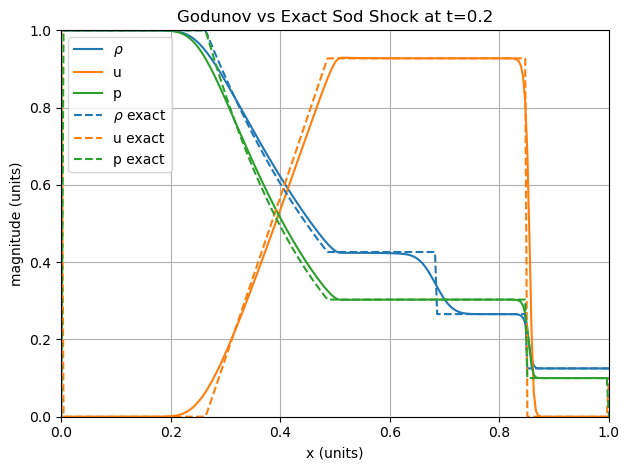

In [89]:
# set ICs again
prim0 = initial_conditions(x)
primGods = [prim0.copy()]

# loop through time
time = 0.
while time < tend:
    # calculate dt and step forward in time
    dt = tend/200
    time = time + dt
    
    # loop through all x except the boundary points
    temp = initial_conditions(x)
    for i in range(1, nx-1):
        # get consv at start
        Uin = Prim2Cons(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
        
        # get fluxes with hllc
        Fiph = HLLC(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2], primGods[-1][i+1][0], primGods[-1][i+1][1], primGods[-1][i+1][2])
        Fimh = HLLC(primGods[-1][i-1][0], primGods[-1][i-1][1], primGods[-1][i-1][2], primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
        
        # do time step
        Uinp1 = -dt*(Fiph - Fimh)/dx + Uin
        temp[i, :] = Cons2Prim(Uinp1[0], Uinp1[1], Uinp1[2])

    # convert to prims and store
    primGods.append(temp)
    
# plot final vals to compare
plt.figure()
plt.title("Godunov vs Exact Sod Shock at t=0.2")
plt.plot(x, primGods[-1][:,0], label=r"$\rho$")
plt.plot(x, primGods[-1][:,1], label="u")
plt.plot(x, primGods[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

We can see that the Godunov HLLC does a good job of capturing the sod shock tube. The pressure and velocity predictions
match the exact solution very closely with some minimal diffusion. The density solution shows much more diffusion,
especially though the shock where there is a very sharp discontinuity. Overall, the solution is very accurate and all
values do converge to the correct magnitude despite the sharp turns being slightly diffused.

# Part 3

## (a) FTBS Consv. Flux

C:\Users\spbro\AppData\Local\Temp\ipykernel_33332\1258865685.py:49: RuntimeWarning: invalid value encountered in sqrt
  speed_sound = np.sqrt(gamma * prim[:,2] / prim[:,0])


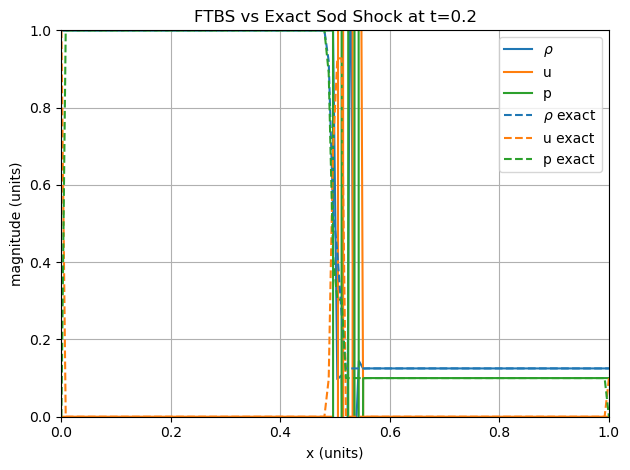

In [90]:
# Example code with FT-BS for 1D Euler equation Sod shock tube problem

# Parameters
gamma = 1.4      # Specific heat ratio
nx = 128         # Number of spatial points
L = 1.0          # Length of domain
dx = L / (nx - 1)
CFL = 0.1        # CFL number
tend = 0.2       # Number of time steps

# Setup the grid
x = np.linspace(0, L, nx)
    
# Point to the initial condition you want to use
initial_conditions = initial_conditions_sod

# Set initial conditions
prim0 = initial_conditions(x)
cons0 = Prim2Cons(prim0[:,0], prim0[:,1], prim0[:,2]).T

# Initialize exact solution object
gamma = 1.4
exact = ExactSodSolver(
    rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
    rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
    gamma=gamma, x0=0.5
)

# Set up the solution array u
cons = cons0.copy()
prim = prim0.copy()

# Set up the exact solution for reference
prim_exact = prim0.copy()

# Store solution at each time step
prims = [prim.copy()]
conss = [cons.copy()]

# Store exact solution at each time step
prim_exacts = [prim_exact.copy()]

# Save L2 norm errors in an array
errors = []

time = 0.0
while(time < tend):   
    # Find dt
    speed_sound = np.sqrt(gamma * prim[:,2] / prim[:,0])
    dt = CFL * dx / (max(abs(prim[:,1])+speed_sound))
     
    # Update time
    time = time + dt
    
    # Numerical solution update
    cons_new = cons.copy()
    prim_new = prim.copy()

    # Time-update
    for i in range(1, nx-1):
        cons_new[i,:] = cons[i,:] \
                    - (dt/dx) * ( flux(prim[i  ,0], prim[i  ,1], prim[i  ,2]) \
                               - flux(prim[i-1,0], prim[i-1,1], prim[i-1,2]) )

    # Update primitive variables from the new conservative variables
    cons = cons_new.copy()
    prim = Cons2Prim(cons[:,0], cons[:,1], cons[:,2]).T

    # Update the overall solution arrays
    conss.append(cons.copy())
    prims.append(prim.copy())
    
    # Exact solution update
    prim_exact = prim.copy()
    for i in range(1, nx-1):
        prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
    prim_exacts.append(prim_exact.copy())
    
    # Calculate L2 norm error between numerical and exact solution
    error = 0.0
    for i in range(1,nx-1):
        error = error + (prim_exact[i]-prim[i])**2
    error = np.sqrt(error/(nx-2))
    errors.append(error)
    
    # Exit loop and stop simulation if the error goes to large
    if (max(error) > 100.):
        break
    
# plot final vals to compare
plt.figure()
plt.title("FTBS vs Exact Sod Shock at t=0.2")
plt.plot(x, prims[-1][:,0], label=r"$\rho$")
plt.plot(x, prims[-1][:,1], label="u")
plt.plot(x, prims[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

As expected, FTBS is unstable. This is not a surprising result since the Euler equations have 3 different wave speeds.
FTBS will only work for linear advection with a wave moving forward in space. It is possible with the Euler equations to
have waves traveling forwards or backwards in space (or both), which means the conditions for which FTBS is stable are
likely to be violated.

## (b) Mac Consv. Flux

C:\Users\spbro\AppData\Local\Temp\ipykernel_33332\316617500.py:49: RuntimeWarning: invalid value encountered in sqrt
  speed_sound = np.sqrt(gamma * prim[:,2] / prim[:,0])


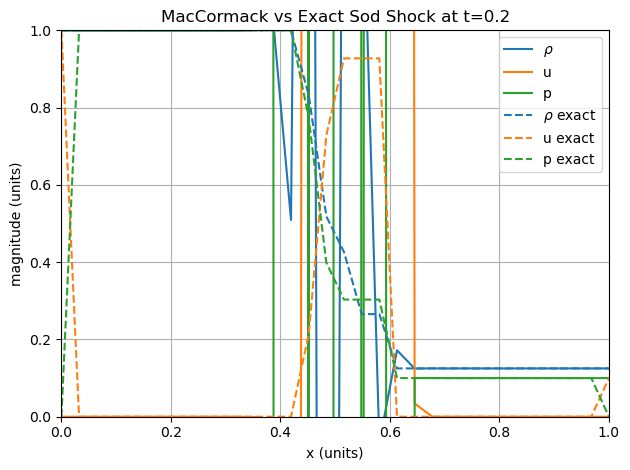

In [91]:
# Example code with MacCormack for 1D Euler equation Sod shock tube problem

# Parameters
gamma = 1.4      # Specific heat ratio
nx = 32         # Number of spatial points
L = 1.0          # Length of domain
dx = L / (nx - 1)
CFL = 0.5        # CFL number
tend = 0.2       # Number of time steps

# Setup the grid
x = np.linspace(0, L, nx)
    
# Point to the initial condition you want to use
initial_conditions = initial_conditions_sod

# Set initial conditions
prim0 = initial_conditions(x)
cons0 = Prim2Cons(prim0[:,0], prim0[:,1], prim0[:,2]).T

# Initialize exact solution object
gamma = 1.4
exact = ExactSodSolver(
    rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
    rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
    gamma=gamma, x0=0.5
)

# Set up the solution array u
cons = cons0.copy()
prim = prim0.copy()

# Set up the exact solution for reference
prim_exact = prim0.copy()

# Store solution at each time step
prims = [prim.copy()]
conss = [cons.copy()]

# Store exact solution at each time step
prim_exacts = [prim_exact.copy()]

# Save L2 norm errors in an array
errors = []

time = 0.0
while(time < tend):   
    # Find dt
    speed_sound = np.sqrt(gamma * prim[:,2] / prim[:,0])
    dt = CFL * dx / (max(abs(prim[:,1])+speed_sound))
     
    # Update time
    time = time + dt
    
    # Numerical solution update
    cons_new = cons.copy()
    prim_new = prim.copy()

    # Time-update
    # First sub time step
    for i in range(1, nx-1):
        cons_star = cons.copy()
        for i in range(1, nx-1):            
            cons_star[i,:] = cons[i,:] \
                       - (dt/dx) * ( flux(prim[i  ,0], prim[i  ,1], prim[i  ,2]) \
                                   - flux(prim[i-1,0], prim[i-1,1], prim[i-1,2]) )
    
    # Update primitives after the first sub time step
    prim = Cons2Prim(cons_star[:,0], cons_star[:,1], cons_star[:,2]).T
        
    # Second sub time step   
    for i in range(1, nx-1):
        for i in range(1, nx-1):            
            cons_new[i,:] = 0.5*(cons[i,:] + cons_star[i,:]) \
                       - 0.5 * (dt/dx) * ( flux(prim[i+1,0], prim[i+1,1], prim[i+1,2]) \
                                         - flux(prim[i  ,0], prim[i  ,1], prim[i  ,2]) )

    # Update primitive variables from the new conservative variables
    cons = cons_new.copy()
    prim = Cons2Prim(cons[:,0], cons[:,1], cons[:,2]).T

    # Update the overall solution arrays
    conss.append(cons.copy())
    prims.append(prim.copy())
    
    # Exact solution update
    prim_exact = prim.copy()
    for i in range(1, nx-1):
        prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
    prim_exacts.append(prim_exact.copy())
    
    # Calculate L2 norm error between numerical and exact solution
    error = 0.0
    for i in range(1,nx-1):
        error = error + (prim_exact[i]-prim[i])**2
    error = np.sqrt(error/(nx-2))
    errors.append(error)

    # Exit loop and stop simulation if the error goes to large
    if (max(error) > 100.):
        break
    
# plot final vals to compare
plt.figure()
plt.title("MacCormack vs Exact Sod Shock at t=0.2")
plt.plot(x, prims[-1][:,0], label=r"$\rho$")
plt.plot(x, prims[-1][:,1], label="u")
plt.plot(x, prims[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

The regular MacCormack scheme is also unstable. This scheme has dispersive errors, which causes problems for the
solution. Furthermore, having waves traveling both directions will break the scheme. MacCormack worked for linear
advection, but the Euler equations have different terms from having multiple wave directions that cause instability.

## (c) Mac Consv. Flux Visc

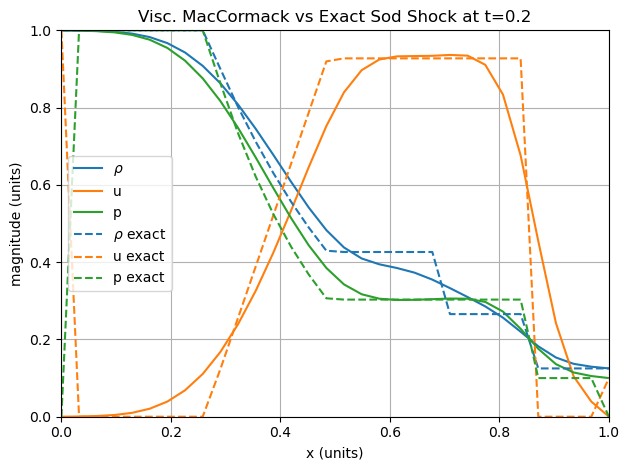

In [104]:
# Example code with MacCormack with added artificial dissipation for 1D Euler equation Sod shock tube problem

# Parameters
gamma = 1.4      # Specific heat ratio

def scheme(nx):
    L = 1.0          # Length of domain
    dx = L / (nx - 1)
    CFL = 0.5        # CFL number
    tend = 0.2       # Number of time steps

    # Setup the grid
    x = np.linspace(0, L, nx)
        
    # Point to the initial condition you want to use
    initial_conditions = initial_conditions_sod

    # Set initial conditions
    prim0 = initial_conditions(x)
    cons0 = Prim2Cons(prim0[:,0], prim0[:,1], prim0[:,2]).T

    # Initialize exact solution object
    gamma = 1.4
    exact = ExactSodSolver(
        rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
        rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
        gamma=gamma, x0=0.5
    )

    # Set up the solution array u
    cons = cons0.copy()
    prim = prim0.copy()

    # Set up the exact solution for reference
    prim_exact = prim0.copy()

    # Store solution at each time step
    prims = [prim.copy()]
    conss = [cons.copy()]

    # Store exact solution at each time step
    prim_exacts = [prim_exact.copy()]

    # Save L2 norm errors in an array
    errors = []

    time = 0.0
    while(time < tend):   
        # Find dt
        speed_sound = np.sqrt(gamma * prim[:,2] / prim[:,0])
        dt = CFL * dx / (max(abs(prim[:,1])+speed_sound))
        
        # Update time
        time = time + dt
        
        # Numerical solution update
        cons_new = cons.copy()
        prim_new = prim.copy()

        # Time-update
        # First sub time step
        for i in range(1, nx-1):
            cons_star = cons.copy()
            for i in range(1, nx-1):            
                cons_star[i,:] = cons[i,:] \
                        - (dt/dx) * ( flux(prim[i  ,0], prim[i  ,1], prim[i  ,2]) \
                                    - flux(prim[i-1,0], prim[i-1,1], prim[i-1,2]) )
        
        # Update primitives after the first sub time step
        prim = Cons2Prim(cons_star[:,0], cons_star[:,1], cons_star[:,2]).T
            
        # Second sub time step   
        for i in range(1, nx-1):
            for i in range(1, nx-1):            
                cons_new[i,:] = 0.5*(cons[i,:] + cons_star[i,:]) \
                        - 0.5 * (dt/dx) * ( flux(prim[i+1,0], prim[i+1,1], prim[i+1,2]) \
                                            - flux(prim[i  ,0], prim[i  ,1], prim[i  ,2]) )

        # Add artificial dissipation
        for i in range(1, nx-1):
            dissipation = 0.1 * (cons_new[i+1,:] - 2*cons_new[i,:] + cons_new[i-1,:])
            cons_new[i,:] = cons_new[i,:] + dissipation
        
        # Update primitive variables from the new conservative variables
        cons = cons_new.copy()
        prim = Cons2Prim(cons[:,0], cons[:,1], cons[:,2]).T

        # Update the overall solution arrays
        conss.append(cons.copy())
        prims.append(prim.copy())
        
        # Exact solution update
        prim_exact = prim.copy()
        for i in range(1, nx-1):
            prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
        prim_exacts.append(prim_exact.copy())
        
        # Calculate L2 norm error between numerical and exact solution
        error = 0.0
        for i in range(1,nx-1):
            error = error + (prim_exact[i]-prim[i])**2
        error = np.sqrt(error/(nx-2))
        errors.append(error)

        # Exit loop and stop simulation if the error goes to large
        if (max(error) > 100.):
            break
        
    return prims, prim_exacts, x

prims, prim_exacts, x = scheme(32)
    
# plot final vals to compare
plt.figure()
plt.title("Visc. MacCormack vs Exact Sod Shock at t=0.2")
plt.plot(x, prims[-1][:,0], label=r"$\rho$")
plt.plot(x, prims[-1][:,1], label="u")
plt.plot(x, prims[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

We can see that adding artificial viscosity stabilizes the MacCormack scheme for the sod shock tube, as expected. This
strategy was used for multiple schemes previously to make them stable.

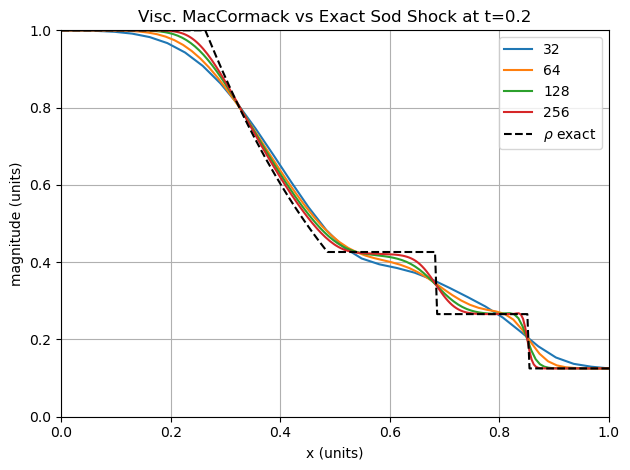

In [105]:
# list of grid spacings to test
nxs = [32, 64, 128, 256]

# loop through and plot
plt.figure()
for nx in nxs:
    prims, prim_exacts, x = scheme(nx)
    
    # plot final vals to compare
    plt.title("Visc. MacCormack vs Exact Sod Shock at t=0.2")
    plt.plot(x, prims[-1][:,0], label=f"{nx:.0f}")

# plot exact solution
plt.plot(x, prim_exacts[-1][:,0], color="k", linestyle="--", label=r"$\rho$ exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

The MacCormack scheme accuracy improves as the grid spacing is decreased. It does come at a large computational cost,
however, taking almost 5 minutes to run all 4 grid spacings. The lowest spacing is very diffused and does not capture
the discontinuities well. The highest resolution is much less diffused but takes a long time to run. The two
intermediate spacings do slightly better than the lowest resolution, but do not quite reach the converged values that
the highest resolution does.

## (d) Split Jacobian Consv.

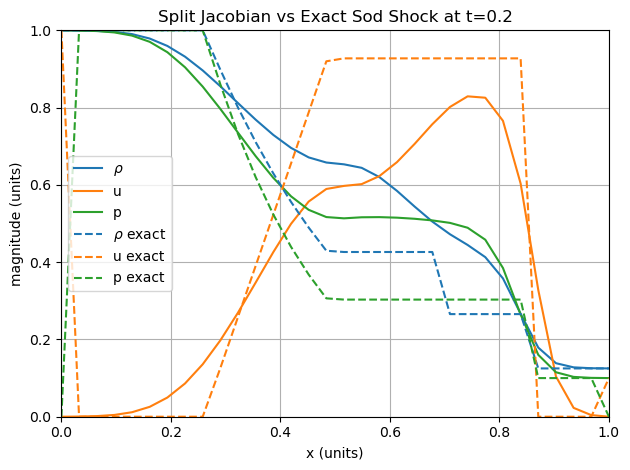

In [94]:
# Example code with Conservative Jacobian splitting for 1D Euler equation Sod shock tube problem
# Caution: this scheme is not discretely "conservative"

# Parameters
gamma = 1.4      # Specific heat ratio

def scheme(nx):
    L = 1.0          # Length of domain
    dx = L / (nx - 1)
    CFL = 0.5        # CFL number
    tend = 0.2       # Number of time steps

    # Setup the grid
    x = np.linspace(0, L, nx)
        
    # Point to the initial condition you want to use
    initial_conditions = initial_conditions_sod

    # Set initial conditions
    prim0 = initial_conditions(x)
    cons0 = Prim2Cons(prim0[:,0], prim0[:,1], prim0[:,2]).T

    # Initialize exact solution object
    gamma = 1.4
    exact = ExactSodSolver(
        rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
        rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
        gamma=gamma, x0=0.5
    )

    # Set up the solution array u
    cons = cons0.copy()
    prim = prim0.copy()

    # Set up the exact solution for reference
    prim_exact = prim0.copy()

    # Store solution at each time step
    prims = [prim.copy()]
    conss = [cons.copy()]

    # Store exact solution at each time step
    prim_exacts = [prim_exact.copy()]

    # Save L2 norm errors in an array
    errors = []

    time = 0.0
    while(time < tend):   
        # Find dt
        speed_sound = np.sqrt(gamma * prim[:,2] / prim[:,0])
        dt = CFL * dx / (max(abs(prim[:,1])+speed_sound))
        
        # Update time
        time = time + dt
        
        # Numerical solution update
        cons_new = cons.copy()
        prim_new = prim.copy()

        # Time-update
        # First sub time step
        for i in range(1, nx-1):
            
            # Get local speed of sound
            a = np.sqrt(gamma * prim[i,2] / prim[i,0])
            # Get local flow-speed
            u = prim[i,1]

            # Get the positive Jacobian as J+ = R A+ L
            # The rgt_eigen and lft_eigen functions provide the left and right eigen vectors that
            # form the matrices V and V_inverse
            J_p = rgt_eigen_cons(prim[i,0], prim[i,1], prim[i,2]) \
                @ np.array( [[max(u-a,0.), 0., 0.], 
                            [0., max(u,0.), 0.], 
                            [0., 0., max(u+a,0.),]] ) \
                @ lft_eigen_cons(prim[i,0], prim[i,1], prim[i,2])
            # Get the negative Jacobian as J- = R A- L
            # The rgt_eigen and lft_eigen functions provide the left and right eigen vectors that
            # form the matrices V and V_inverse
            J_m = rgt_eigen_cons(prim[i,0], prim[i,1], prim[i,2]) \
                @ np.array( [[min(u-a,0.), 0., 0.], 
                            [0., min(u,0.), 0.], 
                            [0., 0., min(u+a,0.), ]] ) \
                @ lft_eigen_cons(prim[i,0], prim[i,1], prim[i,2])

            # Update the conservative variables
            # Use backward differencing with J_p
            cons_new[i,:] = cons[i,:] \
                        - (dt/dx) * ( J_p @ ( cons[i,:] - cons[i-1,:] ) )            
            # Update the conservative variables
            # Use forward differencing with J_m
            cons_new[i,:] = cons_new[i,:] \
                        - (dt/dx) * ( J_m @ ( cons[i+1,:] - cons[i,:] ) )
        
        # Update primitive variables from the new conservative variables
        cons = cons_new.copy()
        prim = Cons2Prim(cons[:,0], cons[:,1], cons[:,2]).T

        # Update the overall solution arrays
        conss.append(cons.copy())
        prims.append(prim.copy())
        
        # Exact solution update
        prim_exact = prim.copy()
        for i in range(1, nx-1):
            prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
        prim_exacts.append(prim_exact.copy())
        
        # Calculate L2 norm error between numerical and exact solution
        error = 0.0
        for i in range(1,nx-1):
            error = error + (prim_exact[i]-prim[i])**2
        error = np.sqrt(error/(nx-2))
        errors.append(error)

        # Exit loop and stop simulation if the error goes to large
        if (max(error) > 100.):
            break
        
    return prims, prim_exacts, x

prims, prim_exacts, x = scheme(32)

# plot final vals to compare
plt.figure()
plt.title("Split Jacobian vs Exact Sod Shock at t=0.2")
plt.plot(x, prims[-1][:,0], label=r"$\rho$")
plt.plot(x, prims[-1][:,1], label="u")
plt.plot(x, prims[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

The split jacobian scheme is stable. This is because we are able to split the different wave directions from the Euler
equations and solve each one with the correct direction scheme based on its direction. It essentially combines FTBS and
FTFS and chooses for which terms to use each scheme.

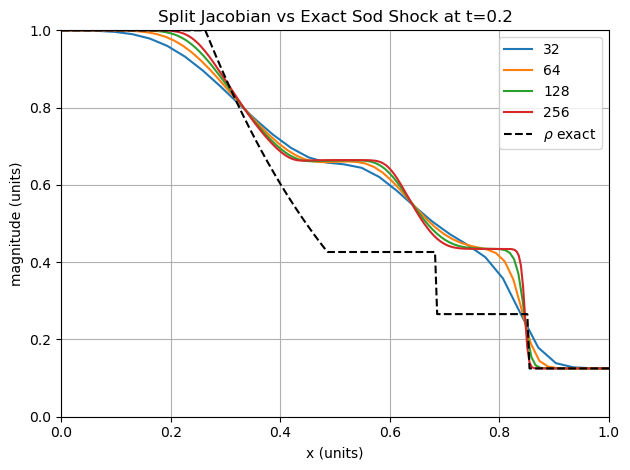

In [95]:
# list of grid spacings to test
nxs = [32, 64, 128, 256]

# loop through and plot
plt.figure()
for nx in nxs:
    prims, prim_exacts, x = scheme(nx)
    
    # plot final vals to compare
    plt.title("Split Jacobian vs Exact Sod Shock at t=0.2")
    plt.plot(x, prims[-1][:,0], label=f"{nx:.0f}")

# plot exact solution
plt.plot(x, prim_exacts[-1][:,0], color="k", linestyle="--", label=r"$\rho$ exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

The split jacobian does not do a very good job capturing the solution. While increasing the resolution allows it to
better capture the discontinuities and sharpness of the solution, it does not improve the accuracy. Whereas the
MacCormack was accurate but diffused for all grid spacings, the split jacobian does not get more accurate. It simply
mispredicts the expected values while becoming a finer solution.

## (e) God HLLC

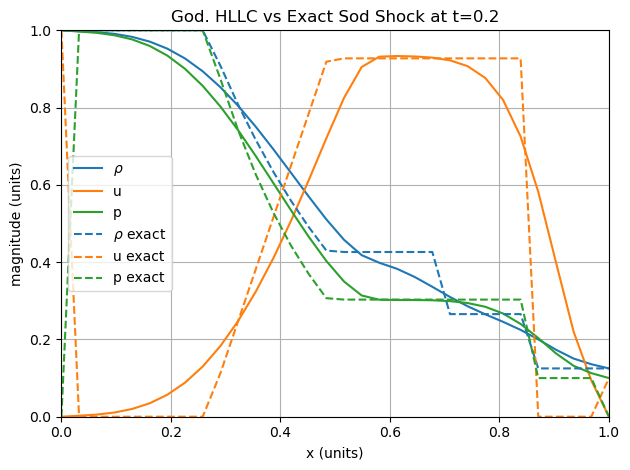

In [96]:
# set up grid
L = 1.

def scheme(nx):
    x = np.linspace(0, L, nx)
    dx = L/nx

    # set up conditions
    gamma = 1.4
    tend = 0.2

    # Point to the initial condition you want to use
    initial_conditions = initial_conditions_sod

    # Set initial conditions
    prim0 = initial_conditions(x)
    primGods = [prim0.copy()]

    # Initialize exact solution object
    exact = ExactSodSolver(
        rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
        rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
        gamma=gamma, x0=0.5
    )

    # Set up the exact solution for reference
    prim_exact = prim0.copy()

    # Store exact solution at each time step
    prim_exacts = [prim_exact.copy()]

    time = 0.0
    while(time < tend):   
        dt = tend/200
        
        # Update time
        time = time + dt
        
        # Exact solution update
        prim_exact = prim_exact.copy()
        for i in range(1, nx-1):
            prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
        prim_exacts.append(prim_exact.copy())
        
        # loop through all x except the boundary points
        temp = initial_conditions(x)
        for i in range(1, nx-1):
            # get consv at start
            Uin = Prim2Cons(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
            
            # get fluxes with hllc
            Fiph = HLLC(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2], primGods[-1][i+1][0], primGods[-1][i+1][1], primGods[-1][i+1][2])
            Fimh = HLLC(primGods[-1][i-1][0], primGods[-1][i-1][1], primGods[-1][i-1][2], primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
            
            # do time step
            Uinp1 = -dt*(Fiph - Fimh)/dx + Uin
            temp[i, :] = Cons2Prim(Uinp1[0], Uinp1[1], Uinp1[2])

        # convert to prims and store
        primGods.append(temp)
        
    return primGods, prim_exacts, x

prims, prim_exacts, x = scheme(32)

# plot final vals to compare
plt.figure()
plt.title("God. HLLC vs Exact Sod Shock at t=0.2")
plt.plot(x, prims[-1][:,0], label=r"$\rho$")
plt.plot(x, prims[-1][:,1], label="u")
plt.plot(x, prims[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

We saw previously that the Godunov HLLC was stable, so this is not surprising that this result is stable.

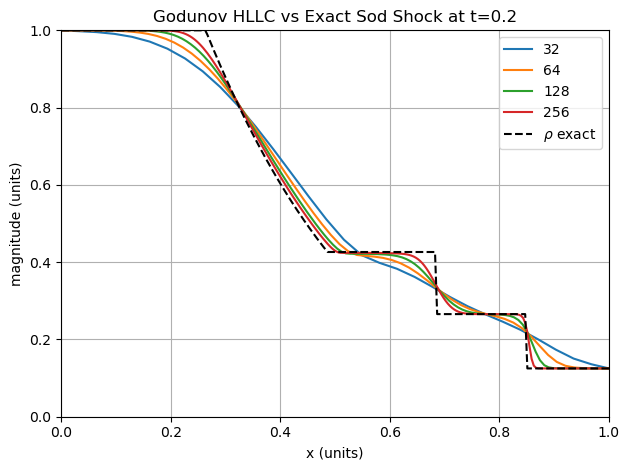

In [97]:
# list of grid spacings to test
nxs = [32, 64, 128, 256]

# loop through and plot
plt.figure()
for nx in nxs:
    prims, prim_exacts, x = scheme(nx)
    
    # plot final vals to compare
    plt.title("Godunov HLLC vs Exact Sod Shock at t=0.2")
    plt.plot(x, prims[-1][:,0], label=f"{nx:.0f}")

# plot exact solution
plt.plot(x, prim_exacts[-1][:,0], color="k", linestyle="--", label=r"$\rho$ exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

We can see that as the grid spacing decreases, the solution gets more accurate. The lowest resolution is very diffused
and significantly misses many important features like the shock and other discontinuities. At the highest resolution,
everything is predicted well except the shock which appears to be diffused. Aside from the lowest resolution, the solver
converges to the correct value with some diffusion.

# Part 4

## a.

In [98]:
def initial_conditions_sod4a(x):
    lft_mask = np.where(x < 0.5)
    rho = np.ones(x.shape) * 0.125
    vel = np.ones(x.shape) * 0.0
    prs = np.ones(x.shape) * 0.1
    
    rho[lft_mask] = 0.125
    vel[lft_mask] = 0.0
    prs[lft_mask] = 1.0
    
    u0 = np.array([rho, vel, prs]).T
    return(u0)

In [99]:
# set up grid
L = 1.
nx = 128
x = np.linspace(0, L, nx)
dx = L/nx

# set up conditions
gamma = 1.4
tend = 0.2

# Point to the initial condition you want to use
initial_conditions = initial_conditions_sod4a

# Set initial conditions
prim0 = initial_conditions(x)

# Initialize exact solution object
exact = ExactSodSolver(
    rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
    rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
    gamma=gamma, x0=0.5
)

# Set up the exact solution for reference
prim_exact = prim0.copy()

# Store exact solution at each time step
prim_exacts = [prim_exact.copy()]

time = 0.0
while(time < tend):   
    dt = tend/200
     
    # Update time
    time = time + dt
    
    # Exact solution update
    prim_exact = prim_exact.copy()
    for i in range(1, nx-1):
        prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
    prim_exacts.append(prim_exact.copy())

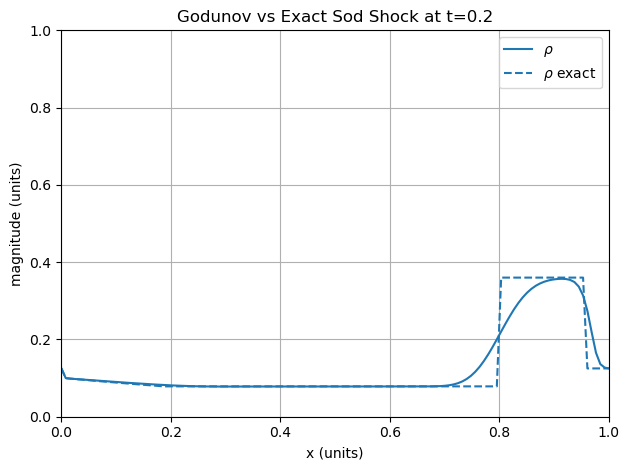

In [100]:
# set ICs again
prim0 = initial_conditions(x)
primGods = [prim0.copy()]

# loop through time
time = 0.
while time < tend:
    # calculate dt and step forward in time
    dt = tend/200
    time = time + dt
    
    # loop through all x except the boundary points
    temp = initial_conditions(x)
    for i in range(1, nx-1):
        # get consv at start
        Uin = Prim2Cons(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
        
        # get fluxes with hllc
        Fiph = HLLC(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2], primGods[-1][i+1][0], primGods[-1][i+1][1], primGods[-1][i+1][2])
        Fimh = HLLC(primGods[-1][i-1][0], primGods[-1][i-1][1], primGods[-1][i-1][2], primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
        
        # do time step
        Uinp1 = -dt*(Fiph - Fimh)/dx + Uin
        temp[i, :] = Cons2Prim(Uinp1[0], Uinp1[1], Uinp1[2])

    # convert to prims and store
    primGods.append(temp)
# plot final vals to compare
plt.figure()
plt.title("Godunov vs Exact Sod Shock at t=0.2")
plt.plot(x, primGods[-1][:,0], label=r"$\rho$")
# plt.plot(x, primGods[-1][:,1], label="u")
# plt.plot(x, primGods[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
# plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
# plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

These ICs give a much different solution. The density has both a sharp increase and decrease far to the right side of
the tube, whereas the original ICs only show a decrease in density from left to right with multiple discontinuities. The
solver does not do a great job of capturing the sharp increase and decrease that are right next to each other. The
diffusive errors do not allow it to reach the correct value and then decrease quickly enough.

## b.

In [101]:
def initial_conditions_sod4b(x):
    lft_mask = np.where(x < 0.5)
    rho = np.ones(x.shape) * 0.125
    vel = np.ones(x.shape) * 0.2
    prs = np.ones(x.shape) * 0.1
    
    rho[lft_mask] = 1.0
    vel[lft_mask] = 0.2
    prs[lft_mask] = 0.1
    
    u0 = np.array([rho, vel, prs]).T
    return(u0)

In [102]:
# set up grid
L = 1.
nx = 128
x = np.linspace(0, L, nx)
dx = L/nx

# set up conditions
gamma = 1.4
tend = 0.2

# Point to the initial condition you want to use
initial_conditions = initial_conditions_sod4b

# Set initial conditions
prim0 = initial_conditions(x)

# Initialize exact solution object
exact = ExactSodSolver(
    rhoL=prim0[0,0], uL=prim0[0,1], pL=prim0[0,2],
    rhoR=prim0[-1,0], uR=prim0[-1,1], pR=prim0[-1,2],
    gamma=gamma, x0=0.5
)

# Set up the exact solution for reference
prim_exact = prim0.copy()

# Store exact solution at each time step
prim_exacts = [prim_exact.copy()]

time = 0.0
while(time < tend):   
    dt = tend/200
     
    # Update time
    time = time + dt
    
    # Exact solution update
    prim_exact = prim_exact.copy()
    for i in range(1, nx-1):
        prim_exact[i,0], prim_exact[i,2], prim_exact[i,1] = exact.sample_full(x[i], time)
    prim_exacts.append(prim_exact.copy())

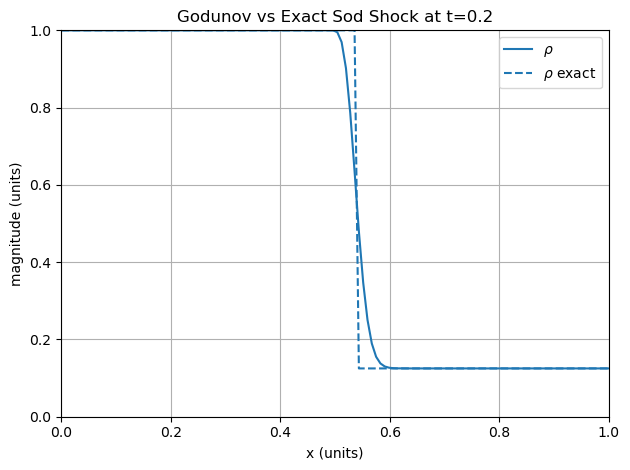

In [103]:
# set ICs again
prim0 = initial_conditions(x)
primGods = [prim0.copy()]

# loop through time
time = 0.
while time < tend:
    # calculate dt and step forward in time
    dt = tend/200
    time = time + dt
    
    # loop through all x except the boundary points
    temp = initial_conditions(x)
    for i in range(1, nx-1):
        # get consv at start
        Uin = Prim2Cons(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
        
        # get fluxes with hllc
        Fiph = HLLC(primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2], primGods[-1][i+1][0], primGods[-1][i+1][1], primGods[-1][i+1][2])
        Fimh = HLLC(primGods[-1][i-1][0], primGods[-1][i-1][1], primGods[-1][i-1][2], primGods[-1][i][0], primGods[-1][i][1], primGods[-1][i][2])
        
        # do time step
        Uinp1 = -dt*(Fiph - Fimh)/dx + Uin
        temp[i, :] = Cons2Prim(Uinp1[0], Uinp1[1], Uinp1[2])

    # convert to prims and store
    primGods.append(temp)
    
# plot final vals to compare
plt.figure()
plt.title("Godunov vs Exact Sod Shock at t=0.2")
plt.plot(x, primGods[-1][:,0], label=r"$\rho$")
# plt.plot(x, primGods[-1][:,1], label="u")
# plt.plot(x, primGods[-1][:,2], label="p")
plt.plot(x, prim_exacts[-1][:,0], color="tab:blue", linestyle="--", label=r"$\rho$ exact")
# plt.plot(x, prim_exacts[-1][:,2], color="tab:orange", linestyle="--", label="u exact")
# plt.plot(x, prim_exacts[-1][:,1], color="tab:green", linestyle="--", label="p exact")
plt.xlabel("x (units)"); plt.ylabel("magnitude (units)")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid()

For these ICs, the solver does a good job capturing the exact solution. Unlike the standard sod shock ICs which have
multiple discontinuous wave fronts, this case only has one shock. The density only changes at that location, but is
stable everywhere else.